In [1]:
from pathlib import Path
from PIL import Image
# pip install Pillow
from collections import Counter
import matplotlib.pyplot as plt
import hashlib
import pandas as pd
from sklearn.model_selection import train_test_split

# 01_data_audit
# 1.1 — check classes

In [2]:
base_path = Path("../../DATA")
folders = [
    base_path / "dataset" / "train",
    base_path / "dataset" / "clean",
    base_path / "datasetv2_TrainClean" / "train",
    base_path / "datasetv2_TrainClean" / "clean",
]
for folder in folders:
    print("\n", folder)
    if folder.exists():
        classes = [x.name for x in folder.iterdir() if x.is_dir()]
        print("Classes:", classes)
    else:
        print("Folder not found!")


 ..\..\DATA\dataset\train
Classes: ['ambulance', 'autobus', 'kamyun', 'minibus', 'savari', 'taxi', 'vanet']

 ..\..\DATA\dataset\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'minibus', 'savari', 'taxi', 'vanet']

 ..\..\DATA\datasetv2_TrainClean\train
Classes: ['ambulance', 'autobus', 'kamyun', 'minibus', 'savari', 'taxi', 'vanet']

 ..\..\DATA\datasetv2_TrainClean\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'minibus', 'savari', 'taxi', 'vanet']


# 1.2 — Number of images

In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
for folder in folders:
    print("\n" + "=" * 50)
    print(folder)
    print("=" * 50)

    total = 0
    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            images = [
                file for file in class_folder.iterdir()
                if file.suffix.lower() in image_extensions
            ]
            count = len(images)
            total += count
            print(f"{class_folder.name:12}:{count}")

    print("-" * 50)
    print(f"{'TOTAL':12}:{total}")


..\..\DATA\dataset\train
ambulance   :50
autobus     :48
kamyun      :100
minibus     :49
savari      :50
taxi        :46
vanet       :48
--------------------------------------------------
TOTAL       :391

..\..\DATA\dataset\clean
ambulance   :49
autobus     :49
kamyun      :99
minibus     :44
savari      :50
taxi        :50
vanet       :95
--------------------------------------------------
TOTAL       :436

..\..\DATA\datasetv2_TrainClean\train
ambulance   :169
autobus     :192
kamyun      :387
minibus     :177
savari      :198
taxi        :198
vanet       :196
--------------------------------------------------
TOTAL       :1517

..\..\DATA\datasetv2_TrainClean\clean
ambulance   :101
autobus     :175
kamyun      :363
minibus     :124
savari      :200
taxi        :190
vanet       :387
--------------------------------------------------
TOTAL       :1540


# 1.3 — Checking format and corrupt file

In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
bad_images = []
for folder in folders:
    for class_folder in folder.iterdir():
        if not class_folder.is_dir():
            continue
        for image_path in class_folder.iterdir():
            if image_path.suffix.lower() not in image_extensions:
                continue
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception as e:
                bad_images.append({
                    "path": str(image_path),
                    "class": class_folder.name,
                    "error": str(e)
                })

print("Number of unreadable images:", len(bad_images))
for item in bad_images:
    print(item["path"])

Number of unreadable images: 0


# 1.4 — Check Image Dimensions

In [5]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
for folder in folders:
    sizes = []
    for class_folder in folder.iterdir():
        if not class_folder.is_dir():
            continue
        for image_path in class_folder.iterdir():
            if image_path.suffix.lower() not in image_extensions:
                continue
            with Image.open(image_path) as img:
                width, height = img.size
                sizes.append((width, height))

    size_counts = Counter(sizes)
    print("\n" + "=" * 60)
    print(folder)
    print("=" * 60)

    print("Number of images:", len(sizes))
    print("\nMost common image sizes:")

    for size, count in size_counts.most_common(10):
        print(f"{size} : {count}")
    min_size = min(sizes, key=lambda x: x[0] * x[1])
    max_size = max(sizes, key=lambda x: x[0] * x[1])
    
    print("\nSmallest image:", min_size)
    print("Largest image:", max_size)


..\..\DATA\dataset\train
Number of images: 391

Most common image sizes:
(198, 264) : 14
(189, 252) : 13
(186, 252) : 11
(177, 240) : 9
(180, 240) : 8
(189, 240) : 7
(198, 252) : 7
(195, 264) : 7
(156, 204) : 6
(162, 216) : 6

Smallest image: (120, 156)
Largest image: (390, 870)

..\..\DATA\dataset\clean
Number of images: 436

Most common image sizes:
(186, 252) : 17
(198, 264) : 16
(177, 240) : 13
(189, 252) : 12
(171, 228) : 6
(210, 276) : 6
(207, 276) : 5
(180, 240) : 5
(177, 228) : 5
(150, 192) : 4

Smallest image: (120, 168)
Largest image: (476, 938)

..\..\DATA\datasetv2_TrainClean\train
Number of images: 1517

Most common image sizes:
(198, 264) : 52
(186, 252) : 51
(189, 252) : 45
(207, 276) : 37
(198, 252) : 29
(177, 240) : 25
(171, 228) : 24
(180, 240) : 24
(210, 276) : 23
(162, 216) : 18

Smallest image: (120, 168)
Largest image: (666, 844)

..\..\DATA\datasetv2_TrainClean\clean
Number of images: 1540

Most common image sizes:
(198, 264) : 53
(189, 252) : 49
(186, 252) : 47

# 1.5 — Show sample images

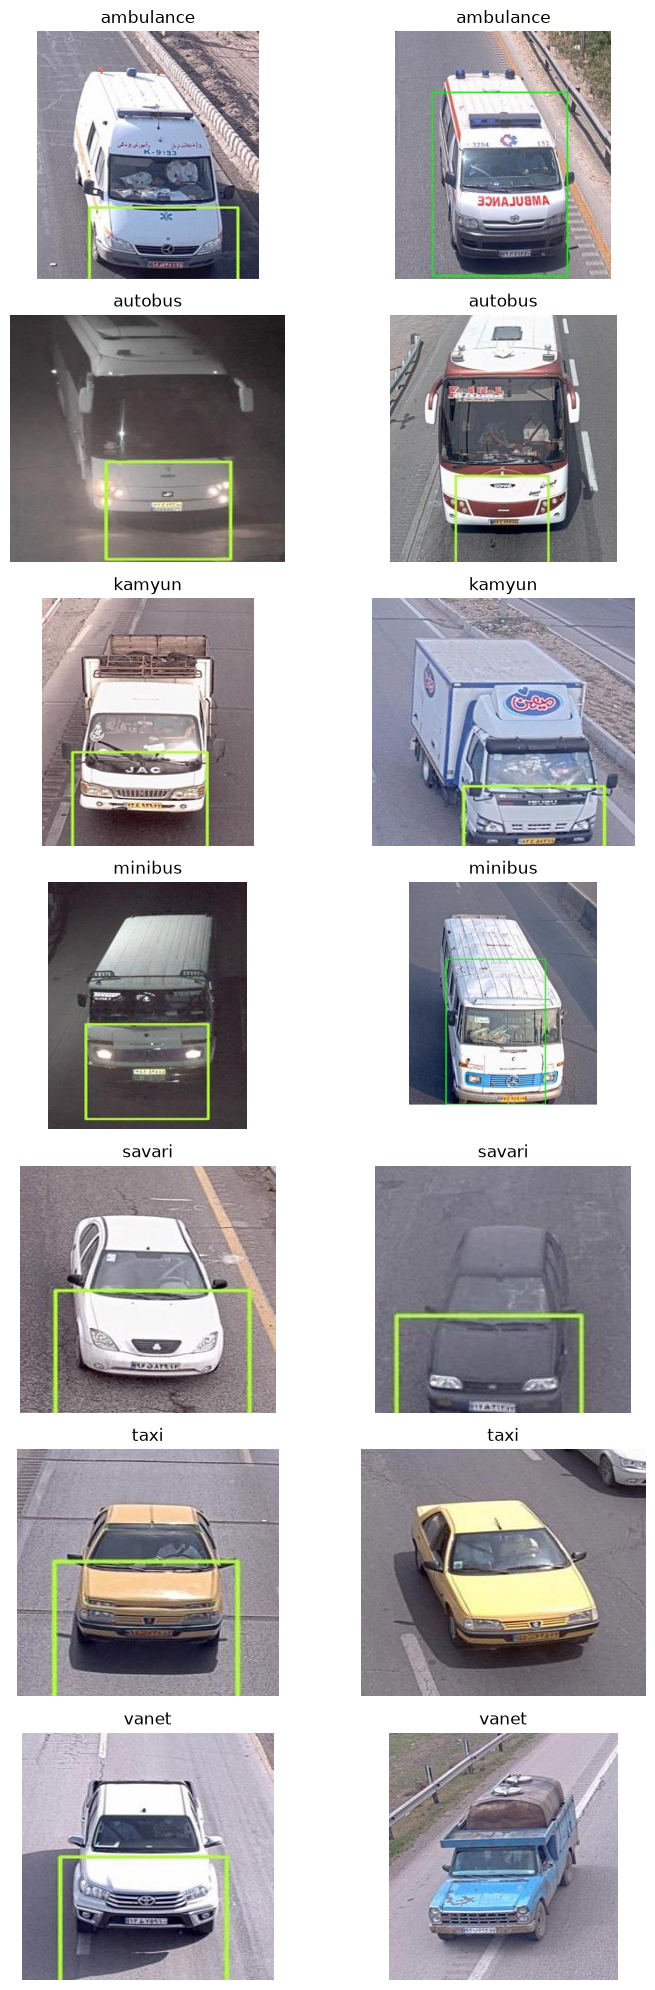

In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
# از هر کلاس فقط 2 تصویر
samples_per_class = 2
# برای جلوگیری از تکرار، اولین تصاویر را از هر کلاس می‌گیریم
samples = {}
for folder in folders:
    for class_folder in sorted(folder.iterdir()):
        if not class_folder.is_dir():
            continue
        class_name = class_folder.name
        # اگر قبلا از این کلاس نمونه گرفته‌ شده، رد شو
        if class_name in samples:
            continue
        images = [
            file for file in sorted(class_folder.iterdir())
            if file.suffix.lower() in image_extensions
        ]
        samples[class_name] = images[:samples_per_class]

fig, axes = plt.subplots(
    len(samples),
    samples_per_class,
    figsize=(8, 20)
)
for row, (class_name, image_paths) in enumerate(samples.items()):
    for col, image_path in enumerate(image_paths):
        image = Image.open(image_path)
        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# 1.6 — Duplicate Check

In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def calculate_hash(image_path):  #برای هر تصویر یک Hash می‌سازد.
    """ محاسبه Hash بر اساس محتوای واقعی فایل تصویر """
    hash_md5 = hashlib.md5()
    with open(image_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

hash_to_files = {}
for folder in folders:
    for class_folder in folder.iterdir():
        if not class_folder.is_dir():
            continue
        for image_path in class_folder.iterdir():
            if image_path.suffix.lower() not in image_extensions:
                continue
            image_hash = calculate_hash(image_path)

            if image_hash not in hash_to_files:
                hash_to_files[image_hash] = []

            hash_to_files[image_hash].append({
                "path": str(image_path),
                "class": class_folder.name
            })

# فقط Hashهایی که بیشتر از یک فایل دارند
duplicate_groups = {
    image_hash: files
    for image_hash, files in hash_to_files.items()
    if len(files) > 1 #این Hash بیشتر از یک فایل دارد؛ پس Duplicate داریم.
}
print("Total unique image contents:", len(hash_to_files))
print("Number of duplicate groups:", len(duplicate_groups))

Total unique image contents: 3868
Number of duplicate groups: 16


In [8]:
for i, (image_hash, files) in enumerate(duplicate_groups.items(), start=1):
    print(f"\n{'=' * 70}")
    print(f"Duplicate Group {i}")
    print(f"Number of files: {len(files)}")

    for file_info in files:
        print(f"  Class: {file_info['class']}")
        print(f"  Path : {file_info['path']}")


Duplicate Group 1
Number of files: 2
  Class: ambulance
  Path : ..\..\DATA\dataset\train\ambulance\199984667.jpg
  Class: ambulance
  Path : ..\..\DATA\dataset\clean\ambulance\199984667.jpg

Duplicate Group 2
Number of files: 2
  Class: ambulance
  Path : ..\..\DATA\dataset\train\ambulance\206808986.jpg
  Class: ambulance
  Path : ..\..\DATA\dataset\clean\ambulance\206808986.jpg

Duplicate Group 3
Number of files: 2
  Class: ambulance
  Path : ..\..\DATA\dataset\train\ambulance\208738861.jpg
  Class: ambulance
  Path : ..\..\DATA\dataset\clean\ambulance\208738861.jpg

Duplicate Group 4
Number of files: 2
  Class: ambulance
  Path : ..\..\DATA\dataset\train\ambulance\213342200.jpg
  Class: ambulance
  Path : ..\..\DATA\dataset\clean\ambulance\213342200.jpg

Duplicate Group 5
Number of files: 2
  Class: ambulance
  Path : ..\..\DATA\dataset\train\ambulance\213801906.jpg
  Class: ambulance
  Path : ..\..\DATA\dataset\clean\ambulance\213801906.jpg

Duplicate Group 6
Number of files: 2
  

# 1.7 — Data Audit Summary

In [ ]:
audit_file = Path("audit_summary.txt")
audit_text = """
========================================
Traffic Vehicle Classification
Data Audit Summary
========================================

FINAL CLASSES
-------------
Number of classes: 7

Classes:
- ambulance
- autobus
- kamyun
- minibus
- savari
- taxi
- vanet


DATA SOURCES
------------
1. DATA/dataset/train
2. DATA/dataset/clean
3. DATA/datasetv2_TrainClean/train
4. DATA/datasetv2_TrainClean/clean


IMAGE COUNTS
------------

DATA/dataset/train
Total: 391

ambulance: 50
autobus: 48
kamyun: 100
minibus: 49
savari: 50
taxi: 46
vanet: 48


DATA/dataset/clean
Total: 436

ambulance: 49
autobus: 49
kamyun: 99
minibus: 44
savari: 50
taxi: 50
vanet: 95


DATA/datasetv2_TrainClean/train
Total: 1517

ambulance: 169
autobus: 192
kamyun: 387
minibus: 177
savari: 198
taxi: 198
vanet: 196


DATA/datasetv2_TrainClean/clean
Total: 1540

ambulance: 101
autobus: 175
kamyun: 363
minibus: 124
savari: 200
taxi: 190
vanet: 387


TOTAL DATASET
-------------
Total images: 3884

ambulance: 369
autobus: 464
kamyun: 949
minibus: 394
savari: 498
taxi: 484
vanet: 726


READABILITY CHECK
-----------------
Unreadable images: 0

DUPLICATE CHECK
---------------
Unique image contents: 3868
Duplicate groups: 16

All detected duplicate groups were within the same class.

No cross-class duplicate conflict was detected.


CONCLUSION
----------
The dataset contains 7 vehicle classes and 3884 image files
across four training sources.

No unreadable images were detected.

16 exact duplicate groups were detected. These duplicates
occurred within the same class and did not create class-label
conflicts.

Image dimensions are not uniform and will be handled later
through the preprocessing/transformation pipeline.

The class distribution is not perfectly balanced and will
be considered in later experiments.
"""

with open(audit_file, "w", encoding="utf-8") as f:
    f.write(audit_text)

print(f"Audit report saved to: {audit_file}")

Audit report saved to: audit_summary.txt


# 02_data_preparation

# 2.1 — Definition of resources and final Dataset classes.

In [10]:
classes = [
    "ambulance",
    "autobus",
    "kamyun",
    "minibus",
    "savari",
    "taxi",
    "vanet",
]
print("Data sources:")
for folder in folders:
    print(folder)

print("\nClasses:")
print(classes)

Data sources:
..\..\DATA\dataset\train
..\..\DATA\dataset\clean
..\..\DATA\datasetv2_TrainClean\train
..\..\DATA\datasetv2_TrainClean\clean

Classes:
['ambulance', 'autobus', 'kamyun', 'minibus', 'savari', 'taxi', 'vanet']


# 2.2 — Collecting the paths of all images from four sources

In [11]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
all_images = []

for folder in folders:
    for class_name in classes:
        class_dir = folder / class_name
        for image_path in class_dir.iterdir():
            if image_path.is_file() and image_path.suffix.lower() in image_extensions:
                all_images.append({
                    "path": image_path,
                    "label": class_name
                })
print("Total images:", len(all_images))

Total images: 3884


In [12]:
label_counts = Counter(item["label"] for item in all_images)

print("Total images:", len(all_images))
print("\nImages per class:")

for class_name in classes:
    print(f"{class_name}: {label_counts[class_name]}")

Total images: 3884

Images per class:
ambulance: 369
autobus: 464
kamyun: 949
minibus: 394
savari: 498
taxi: 484
vanet: 726


# 2.3 — Removing duplicates from the final dataset

In [ ]:
unique_images = []
seen_hashes = set()

for item in all_images:
    h = calculate_hash(item["path"])
    if h not in seen_hashes:
        unique_images.append(item)
        seen_hashes.add(h)

print("Total images:", len(all_images))
print("Unique images:", len(unique_images))
print("Removed duplicates:", len(all_images) - len(unique_images))

Total images: 3884
Unique images: 3868
Removed duplicates: 16


# 2.4 — Analyzing the number of images per class after removing duplicates.

In [14]:
unique_label_counts = Counter(
    item["label"] for item in unique_images)

print("Unique images per class:")

for class_name in classes:
    print(f"{class_name:12}: {unique_label_counts[class_name]}")

print("-" * 30)
print(f"{'TOTAL':12}: {len(unique_images)}")

Unique images per class:
ambulance   : 361
autobus     : 463
kamyun      : 945
minibus     : 392
savari      : 498
taxi        : 484
vanet       : 725
------------------------------
TOTAL       : 3868


# 2.5 — Creating the dataset manifest

In [ ]:
manifest = []
for item in unique_images:
    path = item["path"]
    # پیدا کردن اینکه تصویر از کدام منبع اومده
    source = None
    for folder in folders:
        try:
            path.relative_to(folder)
            source = str(folder)
            break
        except ValueError:
            pass
    manifest.append({
        "path": str(path),
        "label": item["label"],
        "source": source
    })
manifest_df = pd.DataFrame(manifest)

print("Number of images:", len(manifest_df))
print("\nColumns:")
print(manifest_df.columns.tolist())

print("\nFirst 5 rows:")
display(manifest_df.head())

Number of images: 3868

Columns:
['path', 'label', 'source']

First 5 rows:


,path,label,source
0,..\..\DATA\dataset\train\ambulance\198727855.jpg,ambulance,..\..\DATA\dataset\train
1,..\..\DATA\dataset\train\ambulance\199659807.jpg,ambulance,..\..\DATA\dataset\train
2,..\..\DATA\dataset\train\ambulance\199984667.jpg,ambulance,..\..\DATA\dataset\train
3,..\..\DATA\dataset\train\ambulance\203158523.jpg,ambulance,..\..\DATA\dataset\train
4,..\..\DATA\dataset\train\ambulance\203829862.jpg,ambulance,..\..\DATA\dataset\train


# Save Manifest

In [16]:
manifest_path = "../data_splits/all_images.csv"
manifest_df.to_csv(
    manifest_path,
    index=False
)
print("Manifest saved successfully.")
print("Path:", manifest_path)

Manifest saved successfully.
Path: ../data_splits/all_images.csv


# 2.6 — Verify Manifest File

In [17]:
manifest_check = pd.read_csv("../data_splits/all_images.csv")

# تعداد سطرها و ستون‌ها را بررسی می‌کنیم:
print("Number of rows:", len(manifest_check))
print("Columns:", manifest_check.columns.tolist())

# بررسی داده‌های خالی
print("\nMissing values:")
print(manifest_check.isna().sum())  #بررسی می‌کند آیا خانه‌ای خالی (NaN) وجود دارد یا نه

# بررسی تعداد تصاویر هر کلاس
print("\nImages per class:")
print(manifest_check["label"].value_counts())

Number of rows: 3868
Columns: ['path', 'label', 'source']

Missing values:
path      0
label     0
source    0
dtype: int64

Images per class:
label
kamyun       945
vanet        725
savari       498
taxi         484
autobus      463
minibus      392
ambulance    361
Name: count, dtype: int64


# 03_data_split

# 3.1 — Defining Train and Validation Sets

In [18]:
train_df, val_df = train_test_split(
    manifest_check,
    test_size=0.20,
    stratify=manifest_check["label"],
    random_state=42
)
print("Total images :", len(manifest_check))
print("Train images :", len(train_df))
print("Validation images :", len(val_df))

Total images : 3868
Train images : 3094
Validation images : 774


#  3.2 — Analysis of class distribution

In [19]:
print("Train class distribution:")
print(train_df["label"].value_counts().sort_index())  #کلاس‌ها را بر اساس نام مرتب می‌کند

print('-' * 40)

print("Validation class distribution:")
print(val_df["label"].value_counts().sort_index())

Train class distribution:
label
ambulance    289
autobus      370
kamyun       756
minibus      314
savari       398
taxi         387
vanet        580
Name: count, dtype: int64
----------------------------------------
Validation class distribution:
label
ambulance     72
autobus       93
kamyun       189
minibus       78
savari       100
taxi          97
vanet        145
Name: count, dtype: int64


# 3.3 — Split Save

In [20]:
train_df.to_csv(
    "../data_splits/train.csv",
    index=False
)
val_df.to_csv(
    "../data_splits/val.csv",
    index=False
)
print("Train split saved:", len(train_df))
print("Validation split saved:", len(val_df))

Train split saved: 3094
Validation split saved: 774


# 3.4 — Checking for Data Leakage Between Train and Validation Sets

In [21]:
# پیدا کردن مسیرهای مشترک
train_paths = set(train_df["path"])
val_paths = set(val_df["path"])

common_paths = train_paths.intersection(val_paths)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Images appearing in both:", len(common_paths))

Train images: 3094
Validation images: 774
Images appearing in both: 0
